# PyTorch setup
This notebook is currently running on Python 3.14.4. PyTorch wheels are not available for that interpreter on the CUDA indexes we tried, so the install cell now fails fast with a clear message instead of raising a pip traceback.

Use a Python 3.12 or 3.13 kernel for PyTorch, then run the install cell again.

In [5]:
# Install PyTorch if missing.
# This tries a CUDA wheel first so your RTX 3050 can be used.
# If that index does not match your driver/toolchain, use
# the selector at https://pytorch.org/get-started/locally/
import importlib.util, sys, subprocess
py_ver = sys.version_info
if py_ver >= (3, 14):
    print(f'Running Python {py_ver.major}.{py_ver.minor}. Prebuilt CUDA wheels are not available for this interpreter.')
    print('Options: 1) Switch the notebook kernel to Python 3.12/3.13 (recommended). 2) Install CPU-only PyTorch (no CUDA).')
    try:
        print('Attempting to install CPU-only PyTorch to proceed without GPU...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', 'torch', 'torchvision', '--index-url', 'https://download.pytorch.org/whl/cpu'])
        print('CPU-only PyTorch install complete (no CUDA).')
    except subprocess.CalledProcessError as e:
        print('CPU-only PyTorch install failed:', e)
        print('Please switch your kernel to Python 3.12 or 3.13 for CUDA support and rerun this cell.')
else:
    torch_spec = importlib.util.find_spec('torch')
    needs_cuda_install = True
    if torch_spec is not None:
        import torch
        needs_cuda_install = not bool(torch.version.cuda)
    if needs_cuda_install:
        print('Installing or upgrading to CUDA-enabled PyTorch (attempt)')
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', '--force-reinstall', 'torch', 'torchvision', '--index-url', 'https://download.pytorch.org/whl/cu121'])
        except subprocess.CalledProcessError as e:
            print('CUDA wheel install failed:', e)
            print('Falling back to CPU-only PyTorch install')
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', 'torch', 'torchvision', '--index-url', 'https://download.pytorch.org/whl/cpu'])
    else:
        print('CUDA-enabled PyTorch already installed')

CUDA-enabled PyTorch already installed


In [6]:
# run this in a notebook cell after installation cell above
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    try:
        print("GPU name:      ", torch.cuda.get_device_name(0))
        print("VRAM total:    ", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")
    except Exception as e:
        print('Error querying GPU properties:', e)
else:
    print('No CUDA GPU available.')

CUDA available: True
GPU name:       NVIDIA GeForce RTX 3050 Laptop GPU
VRAM total:     4.0 GB


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
# torchinfo provides a nice model summary. If it's missing, use a fallback.
try:
    from torchinfo import summary
except Exception:
    def summary(model, input_size=None, device=None):
        total_params = sum(p.numel() for p in model.parameters())
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'Fallback summary — total params: {total_params:,}, trainable: {trainable:,}')
        try:
            for name, param in model.named_parameters():
                print(name, tuple(param.shape))
        except Exception:
            pass
        return None
import time, os

# ─── CONFIG — tune these to push harder ───────────────────────────────────────
BATCH_SIZE   = 512       # increase to 1024 if you have 8+ GB VRAM
EPOCHS       = 30
LR           = 0.001
NUM_WORKERS  = 4
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ──────────────────────────────────────────────────────────────────────────────

print(f"Running on: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── DATA ──────────────────────────────────────────────────────────────────────
# aggressive augmentation = more GPU work per image
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
inference_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
    image = Image.open(image_path).convert('RGB')
    original_preview = image.copy().resize((256, 256))
    original_path = Path('prediction_original.png')
    original_preview.save(original_path)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    tensor = inference_transform(image).unsqueeze(0)
                         (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True)   # pin_memory speeds up CPU→GPU transfer
testloader = torch.utils.data.DataLoader(
    testset,  batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True)

# ── MODEL — ResNet-style with residual connections ───────────────────────────
class ResBlock(nn.Module):
    """One residual block: two conv layers + a skip connection."""
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(x + self.block(x))   # skip connection: output + input

class DeepCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Stage 1: 3→64 channels
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            ResBlock(64), ResBlock(64),
            nn.MaxPool2d(2),   # 32→16

            # Stage 2: 64→128 channels
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            ResBlock(128), ResBlock(128),
            nn.MaxPool2d(2),   # 16→8

            # Stage 3: 128→256 channels
            nn.Conv2d(128, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            ResBlock(256), ResBlock(256),
            nn.MaxPool2d(2),   # 8→4

            # Stage 4: 256→512 channels
            nn.Conv2d(256, 512, 3, padding=1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            ResBlock(512),
            nn.AdaptiveAvgPool2d(1),  # 4→1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = DeepCNN().to(DEVICE)

# print model summary — shows param count and layer shapes
summary(model, input_size=(1, 3, 32, 32), device=DEVICE)

# ── TRAINING SETUP ───────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR * 10,
    steps_per_epoch=len(trainloader), epochs=EPOCHS
)

# Mixed precision — runs faster, uses less VRAM, pushes GPU harder
scaler = torch.cuda.amp.GradScaler()

# ── TRAINING LOOP ─────────────────────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [], 'test_acc': []}
from PIL import Image, ImageDraw, ImageFont
import math
print("Your fans should start spinning shortly...\n")

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    t0 = time.time()

    for inputs, labels in trainloader:
        # move batch to GPU — this is the CPU→GPU transfer
        inputs, labels = inputs.to(DEVICE, non_blocking=True), \
                         labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        # mixed precision forward pass (fp16 on GPU, fp32 accumulation)
        with torch.cuda.amp.autocast():
            outputs = model(inputs)
            loss    = criterion(outputs, labels)

        # backward pass — this fires the backprop CUDA kernels
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total   += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc  = 100. * correct / total
    train_loss = running_loss / len(trainloader)

    # ── EVALUATION ───────────────────────────────────────────────────────────
    model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
            _, predicted = outputs.max(1)
            test_total   += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()

    test_acc = 100. * test_correct / test_total
    elapsed  = time.time() - t0

    # GPU memory stats
    mem_used = torch.cuda.memory_allocated(0) / 1e6
    mem_peak = torch.cuda.max_memory_allocated(0) / 1e6

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS}  "
          f"loss: {train_loss:.3f}  "
          f"train: {train_acc:.1f}%  "
          f"test: {test_acc:.1f}%  "
          f"time: {elapsed:.1f}s  "
          f"VRAM: {mem_used:.0f}/{mem_peak:.0f} MB")

# ── SAVE MODEL ───────────────────────────────────────────────────────────────
torch.save(model.state_dict(), 'cifar10_cnn.pth')
print(f"\nModel saved → cifar10_cnn.pth")
print(f"Final test accuracy: {history['test_acc'][-1]:.1f}%")

Running on: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
VRAM: 4.0 GB
Files already downloaded and verified
Files already downloaded and verified
Fallback summary — total params: 9,506,634, trainable: 9,506,634
features.0.weight (64, 3, 3, 3)
features.1.weight (64,)
features.1.bias (64,)
features.3.block.0.weight (64, 64, 3, 3)
features.3.block.1.weight (64,)
features.3.block.1.bias (64,)
features.3.block.3.weight (64, 64, 3, 3)
features.3.block.4.weight (64,)
features.3.block.4.bias (64,)
features.4.block.0.weight (64, 64, 3, 3)
features.4.block.1.weight (64,)
features.4.block.1.bias (64,)
features.4.block.3.weight (64, 64, 3, 3)
features.4.block.4.weight (64,)
features.4.block.4.bias (64,)
features.6.weight (128, 64, 3, 3)
features.7.weight (128,)
features.7.bias (128,)
features.9.block.0.weight (128, 128, 3, 3)
features.9.block.1.weight (128,)
features.9.block.1.bias (128,)
features.9.block.3.weight (128, 128, 3, 3)
features.9.block.4.weight (128,)
features.9.block.4.bias (128,)
fea

/tmp/ipykernel_133729/3076778511.py:134: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_133729/3076778511.py:155: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


KeyboardInterrupt: 

# Use the trained model
This section reloads `cifar10_cnn.pth`, evaluates it on the CIFAR-10 test set, and runs predictions on your own image files.

Important: this model was trained on CIFAR-10 classes, so it can only predict those 10 labels. It will still accept natural images, but results on arbitrary photos may be weak unless the image resembles CIFAR-10 style objects.

In [7]:
from pathlib import Path
from PIL import Image, ImageDraw
from IPython.display import display
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])
inference_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(x + self.block(x))

class DeepCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            ResBlock(64), ResBlock(64),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            ResBlock(128), ResBlock(128),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            ResBlock(256), ResBlock(256),
            nn.MaxPool2d(2),
            nn.Conv2d(256, 512, 3, padding=1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            ResBlock(512),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

weights_path = Path('cifar10_cnn.pth')
if not weights_path.exists():
    raise FileNotFoundError('Could not find cifar10_cnn.pth. Run the training cell first or place the weights file in this folder.')

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=128, shuffle=False, num_workers=2, pin_memory=(DEVICE.type == 'cuda'))

model = DeepCNN().to(DEVICE)
state_dict = torch.load(weights_path, map_location=DEVICE)
model.load_state_dict(state_dict)
model.eval()
print(f'Loaded weights from {weights_path.resolve()}')

def predict_tensor(batch_tensor):
    batch_tensor = batch_tensor.to(DEVICE)
    with torch.no_grad():
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            logits = model(batch_tensor)
            probs = torch.softmax(logits, dim=1)
    top_probs, top_idxs = probs.topk(3, dim=1)
    return top_probs.cpu(), top_idxs.cpu()

def predict_image(image_path='/home/vincenzo/Downloads/car.webp'):
    image = Image.open(image_path).convert('RGB')

    original_preview = image.copy().resize((256, 256))
    original_path = Path('prediction_original.png')
    original_preview.save(original_path)

    display_image = image.resize((256, 256))
    tensor = inference_transform(image).unsqueeze(0)

    top_probs, top_idxs = predict_tensor(tensor)

    top_probs = top_probs[0].tolist()
    top_idxs = top_idxs[0].tolist()

    preview = display_image.copy()
    draw = ImageDraw.Draw(preview)

    draw.rectangle([0, 0, preview.width, 28], fill=(0, 0, 0))
    draw.text((8, 6), 'Input image', fill=(255, 255, 255))

    preview_path = Path('prediction_preview.png')
    preview.save(preview_path)

    print(f'Saved original input to {original_path.resolve()}')
    print(f'Saved preview to {preview_path.resolve()}')
    print('Note: the model sees the image resized to 32x32 because it was trained on CIFAR-10-sized inputs.')
    display(preview)
    print('Top predictions:')

    for prob, idx in zip(top_probs, top_idxs):
        print(f'  {class_names[idx]:>10s}: {prob*100:.2f}%')

    return class_names[top_idxs[0]], top_probs[0]

def show_test_predictions(n=8):
    samples = torch.utils.data.Subset(testset, list(range(n)))
    loader = torch.utils.data.DataLoader(samples, batch_size=n, shuffle=False)
    images, labels = next(iter(loader))
    images = images.to(DEVICE)
    with torch.no_grad():
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
    top_probs, top_idxs = probs.topk(1, dim=1)
    images = images.cpu()
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
    tile_w, tile_h = 260, 300
    cols = 4
    rows = math.ceil(n / cols)
    canvas = Image.new('RGB', (cols * tile_w, rows * tile_h), (20, 20, 20))
    draw = ImageDraw.Draw(canvas)
    for idx, (img, true_label, pred_idx, pred_prob) in enumerate(zip(images, labels, top_idxs.squeeze(1), top_probs.squeeze(1))):
        row, col = divmod(idx, cols)
        x0, y0 = col * tile_w, row * tile_h
        img = (img * std + mean).clamp(0, 1)
        img = (img.permute(1, 2, 0).numpy() * 255).astype('uint8')
        tile = Image.fromarray(img).resize((240, 240))
        canvas.paste(tile, (x0 + 10, y0 + 10))
        caption = f'True: {class_names[true_label]} | Pred: {class_names[pred_idx]} ({pred_prob.item()*100:.1f}%)'
        draw.text((x0 + 10, y0 + 260), caption, fill=(255, 255, 255))
    gallery_path = Path('test_predictions_gallery.png')
    canvas.save(gallery_path)
    print(f'Saved gallery to {gallery_path.resolve()}')

def evaluate_test_set():
    loss_sum = 0.0
    correct = 0
    total = 0
    per_class_correct = [0] * 10
    per_class_total = [0] * 10
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
                outputs = model(images)
                loss = criterion(outputs, labels)
            loss_sum += loss.item() * labels.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            for label, pred in zip(labels, preds):
                per_class_total[label.item()] += 1
                per_class_correct[label.item()] += int(label.item() == pred.item())
    avg_loss = loss_sum / total
    accuracy = 100.0 * correct / total
    print(f'Test loss: {avg_loss:.4f}')
    print(f'Test accuracy: {accuracy:.2f}%')
    print('Per-class accuracy:')
    for name, corr, tot in zip(class_names, per_class_correct, per_class_total):
        print(f'  {name:>10s}: {100.0 * corr / tot:5.1f}%')
    return {'loss': avg_loss, 'accuracy': accuracy, 'per_class_correct': per_class_correct, 'per_class_total': per_class_total}

# Run one of these explicitly after the cell executes:
# predict_image('/home/vincenzo/Downloads/car.webp')
# metrics = evaluate_test_set()
# show_test_predictions(n=8)

Files already downloaded and verified
Loaded weights from /home/vincenzo/Documents/cuda-programming/cifar10_cnn.pth


/tmp/ipykernel_133729/2119698571.py:83: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weights_path, map_location=DEVICE)


Saved original input to /home/vincenzo/Documents/cuda-programming/prediction_original.png
Saved preview to /home/vincenzo/Documents/cuda-programming/prediction_preview.png
Note: the model sees the image resized to 32x32 because it was trained on CIFAR-10-sized inputs.


/tmp/ipykernel_133729/2119698571.py:91: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):


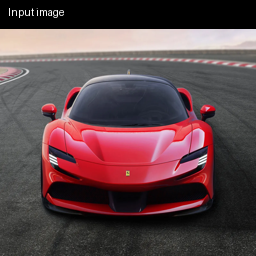

Top predictions:
  automobile: 91.21%
        ship: 1.06%
    airplane: 1.04%


('automobile', 0.912084698677063)

In [8]:
predict_image()